In [144]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import librosa.display
import plotly.express as px
import ipywidgets as widgets

from IPython.display import Audio, display, Markdown

from src.data_utils import scan_audio_dataset
from src.features import EncodecFeatureExtractor, CLAPFeatureExtractor, extract_all_features
from src.analysis import (
    split_feature_sets,
    prepare_matrix,
    compute_pca,
    compute_umap,
    compute_silhouette,
)

In [145]:
DATA_DIR = "data/music_radar"
OUTPUT_DIR = Path("data/features_musicradar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COLORS = {
    "Bass": "#00f5d4",
    "Claps": "#ff4d6d",
    "Cymbals": "#ffd60a",
    "FX n Noise": "#9b5de5",
    "Hats": "#f15bb5",
    "Hi Perc": "#00bbf9",
    "Kicks": "#ff006e",
    "Lo Perc": "#adb5bd",
    "Snares": "#fb5607",
    "Synth1": "#3a86ff",
    "Synth2": "#8338ec",
}

BG_COLOR = "#0b0b0f"
AX_COLOR = "#12131a"
GRID_COLOR = "#2a2d36"
TEXT_COLOR = "#f5f5f5"

plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = AX_COLOR
plt.rcParams["savefig.facecolor"] = BG_COLOR
plt.rcParams["axes.edgecolor"] = "#3a3d46"
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["text.color"] = TEXT_COLOR
plt.rcParams["axes.titlecolor"] = TEXT_COLOR
plt.rcParams["grid.color"] = GRID_COLOR
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [146]:
DATA_DIR = "data/music_radar"
OUTPUT_DIR = Path("data/features_musicradar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [147]:
df = scan_audio_dataset(DATA_DIR)
df.head()

,filepath,filename,label
0,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_01.wav,Bass
1,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_02.wav,Bass
2,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_03.wav,Bass
3,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_04.wav,Bass
4,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_05.wav,Bass


In [148]:
label_counts = df["label"].value_counts().sort_index()
label_counts

label
Bass          20
Claps         24
Cymbals       20
FX n Noise    46
Hats          44
Hi Perc       48
Kicks         32
Lo Perc       46
Snares        34
Synth1        37
Synth2        48
Name: count, dtype: int64

In [149]:
dataset_summary = pd.DataFrame({
    "category": label_counts.index,
    "n_files": label_counts.values
})
dataset_summary

,category,n_files
0,Bass,20
1,Claps,24
2,Cymbals,20
3,FX n Noise,46
4,Hats,44
5,Hi Perc,48
6,Kicks,32
7,Lo Perc,46
8,Snares,34
9,Synth1,37


In [150]:
feat_df = pd.read_csv(OUTPUT_DIR / "features.csv")
feat_df.head()

,filepath,filename,label,duration_sec,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,onset_strength_mean,...,clap_502,clap_503,clap_504,clap_505,clap_506,clap_507,clap_508,clap_509,clap_510,clap_511
0,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_01.wav,Bass,0.839250,0.201376,0.001392,49.600850,213.615551,34.277344,0.023498,...,-0.020207,-0.041948,0.002677,-0.017239,-0.035522,-0.035192,-0.011515,0.038550,0.037811,0.009857
1,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_02.wav,Bass,0.981708,0.168224,0.004166,97.083289,297.447641,79.288564,0.108541,...,-0.021284,-0.019021,0.000583,-0.023646,-0.032732,-0.036639,-0.030294,-0.007177,0.033138,0.049140
2,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_03.wav,Bass,1.605750,0.065593,0.001394,32.528196,117.055360,54.276316,0.041477,...,-0.020461,-0.016502,0.003830,-0.023476,-0.026033,-0.034912,-0.015136,0.000811,0.027155,0.049519
3,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_04.wav,Bass,1.178417,0.049918,0.003148,352.260350,1203.629445,221.609933,0.129767,...,-0.017271,-0.018306,0.016168,0.012882,-0.029095,-0.001993,-0.042872,0.038891,0.001049,0.066114
4,/Users/martinsssssss/Desktop/SMC/Generative Al...,TB_Kick[Hit]_05.wav,Bass,1.537917,0.090269,0.001338,35.818996,113.431246,47.838185,0.036262,...,-0.014372,-0.009711,-0.002995,-0.005186,-0.041909,-0.031926,-0.023445,0.015210,0.047668,0.017442


In [151]:
#encodec_extractor = EncodecFeatureExtractor()
#clap_extractor = CLAPFeatureExtractor()

In [152]:
"""
rows = []

for i, row in df.iterrows():
    print(f"[{i+1}/{len(df)}] {row['filename']}")
    feats = extract_all_features(
        row["filepath"],
        encodec_extractor=encodec_extractor,
        clap_extractor=clap_extractor,
    )
    rows.append({**row.to_dict(), **feats})

feat_df = pd.DataFrame(rows)
feat_df.head()
"""

'\nrows = []\n\nfor i, row in df.iterrows():\n    print(f"[{i+1}/{len(df)}] {row[\'filename\']}")\n    feats = extract_all_features(\n        row["filepath"],\n        encodec_extractor=encodec_extractor,\n        clap_extractor=clap_extractor,\n    )\n    rows.append({**row.to_dict(), **feats})\n\nfeat_df = pd.DataFrame(rows)\nfeat_df.head()\n'

In [153]:
#feat_df.to_csv(OUTPUT_DIR / "features.csv", index=False)
#print("Saved:", OUTPUT_DIR / "features.csv")

In [154]:
classical_cols, encodec_cols, clap_cols = split_feature_sets(feat_df)

print("Classical features:", len(classical_cols))
print("Encodec features:", len(encodec_cols))
print("CLAP features:", len(clap_cols))

Classical features: 107
Encodec features: 162
CLAP features: 512


In [155]:
X_classical, _ = prepare_matrix(feat_df, classical_cols)
X_encodec, _ = prepare_matrix(feat_df, encodec_cols)
X_clap, _ = prepare_matrix(feat_df, clap_cols)

In [156]:
Zc_umap, _ = compute_umap(X_classical)
Ze_umap, _ = compute_umap(X_encodec)
Zcl_umap, _ = compute_umap(X_clap)

In [157]:
plot_classical = feat_df.copy()
plot_classical["x"] = Zc_umap[:, 0]
plot_classical["y"] = Zc_umap[:, 1]

plot_encodec = feat_df.copy()
plot_encodec["x"] = Ze_umap[:, 0]
plot_encodec["y"] = Ze_umap[:, 1]

plot_clap = feat_df.copy()
plot_clap["x"] = Zcl_umap[:, 0]
plot_clap["y"] = Zcl_umap[:, 1]

print("plot_classical ready")
print("plot_encodec ready")
print("plot_clap ready")

plot_classical ready
plot_encodec ready
plot_clap ready


In [158]:
classical_sil = compute_silhouette(X_classical, feat_df["label"].values)
encodec_sil = compute_silhouette(X_encodec, feat_df["label"].values)
clap_sil = compute_silhouette(X_clap, feat_df["label"].values)

scores_df = pd.DataFrame([
    {"feature_set": "classical", "silhouette_score": classical_sil},
    {"feature_set": "encodec", "silhouette_score": encodec_sil},
    {"feature_set": "clap", "silhouette_score": clap_sil},
])

scores_df

,feature_set,silhouette_score
0,classical,0.094669
1,encodec,0.028567
2,clap,0.300551


In [159]:
scores_df.to_csv(OUTPUT_DIR / "silhouette_scores.csv", index=False)
dataset_summary.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
print("Saved report tables.")

Saved report tables.


In [160]:
def make_interactive_plot(plot_df, title="Interactive plot"):
    fig = px.scatter(
        plot_df,
        x="x",
        y="y",
        color="label",
        color_discrete_map=LABEL_COLORS,
        hover_data=["filename", "label"],
        category_orders={"label": sorted(plot_df["label"].unique())},
        title=title,
    )

    fig.update_traces(
        marker=dict(
            size=11,
            line=dict(width=1, color="white"),
            opacity=0.92
        )
    )

    fig.update_layout(
        paper_bgcolor=BG_COLOR,
        plot_bgcolor=AX_COLOR,
        font=dict(color=TEXT_COLOR, size=12),
        title_font=dict(size=18, color=TEXT_COLOR),
        legend_title_text="Category",
        xaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=False, color=TEXT_COLOR),
        yaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=False, color=TEXT_COLOR),
        height=700,
        width=1100,
    )

    return fig

In [161]:
make_interactive_plot(plot_classical, "Classical Audio Descriptors - UMAP")

In [162]:
make_interactive_plot(plot_encodec, "Encodec Features - UMAP")

In [163]:
make_interactive_plot(plot_encodec, "CLAP Embeddings - UMAP")

In [177]:
def show_audio_details(filename):
    row = feat_df[feat_df["filename"] == filename].iloc[0]

    display(Markdown(f"### {row['filename']}"))
    display(Markdown(f"**Category:** {row['label']}"))

    y, sr = librosa.load(row["filepath"], sr=None, mono=True)

    # waveform
    fig, ax = plt.subplots(figsize=(10, 3), facecolor=BG_COLOR)
    ax.set_facecolor(AX_COLOR)
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title("Waveform", color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_color("#3a3d46")
    plt.tight_layout()
    plt.show()

    # spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG_COLOR)
    ax.set_facecolor(AX_COLOR)
    img = librosa.display.specshow(
        D,
        sr=sr,
        x_axis="time",
        y_axis="log",
        cmap="magma",
        ax=ax
    )
    cbar = plt.colorbar(img, format="%+2.0f dB")
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=TEXT_COLOR)
    ax.set_title("Spectrogram", color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_color("#3a3d46")
    plt.tight_layout()
    plt.show()

    # audio player
    display(Audio(row["filepath"]))

    # a few useful numeric features
    preview_cols = [c for c in [
        "rms_mean",
        "zcr_mean",
        "spectral_centroid_mean",
        "spectral_bandwidth_mean",
        "spectral_rolloff_mean",
        "onset_strength_mean",
        "encodec_num_codebooks",
        "encodec_total_frames",
        "clap_dim",
    ] if c in row.index]

    preview_df = pd.DataFrame({
        "feature": preview_cols,
        "value": [row[c] for c in preview_cols]
    })
    display(preview_df)

In [178]:
audio_dropdown = widgets.Dropdown(
    options=sorted(feat_df["filename"].tolist()),
    description="Audio:",
    layout=widgets.Layout(width="700px")
)

widgets.interact(show_audio_details, filename=audio_dropdown);

interactive(children=(Dropdown(description='Audio:', layout=Layout(width='700px'), options=('Rave_Lead_A#1.wav…

In [179]:
feat_df[[
    "filename",
    "label",
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
    "onset_strength_mean",
    "encodec_num_codebooks",
    "encodec_total_frames",
    "clap_dim"
]].head(10)

,filename,label,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,onset_strength_mean,encodec_num_codebooks,encodec_total_frames,clap_dim
0,TB_Kick[Hit]_01.wav,Bass,0.201376,0.001392,49.600850,213.615551,34.277344,0.023498,8,63,512
1,TB_Kick[Hit]_02.wav,Bass,0.168224,0.004166,97.083289,297.447641,79.288564,0.108541,8,74,512
2,TB_Kick[Hit]_03.wav,Bass,0.065593,0.001394,32.528196,117.055360,54.276316,0.041477,8,121,512
3,TB_Kick[Hit]_04.wav,Bass,0.049918,0.003148,352.260350,1203.629445,221.609933,0.129767,8,89,512
4,TB_Kick[Hit]_05.wav,Bass,0.090269,0.001338,35.818996,113.431246,47.838185,0.036262,8,116,512
5,TB_Kick[Hit]_06.wav,Bass,0.196970,0.002745,141.642728,329.034237,317.673142,0.042423,8,58,512
6,TB_Kick[Hit]_07.wav,Bass,0.114384,0.004883,140.791619,282.425496,283.353365,0.060031,8,62,512
7,TB_Kick[Hit]_08.wav,Bass,0.099692,0.004972,417.202966,1304.423208,461.647727,0.034209,8,52,512
8,TB_Kick[Hit]_09.wav,Bass,0.090755,0.003743,235.222233,740.219350,362.630208,0.046788,8,115,512
9,TB_Kick[Hit]_10.wav,Bass,0.130109,0.004395,309.788805,865.609892,443.065068,0.083230,8,116,512


In [180]:
summary_cols = [
    c for c in [
        "rms_mean",
        "zcr_mean",
        "spectral_centroid_mean",
        "spectral_bandwidth_mean",
        "spectral_rolloff_mean",
        "onset_strength_mean",
    ] if c in feat_df.columns
]

category_summary = feat_df.groupby("label")[summary_cols].mean().round(3)
category_summary

,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,onset_strength_mean
label,,,,,,
Bass,0.108,0.005,184.190,454.249,283.661,0.048
Claps,0.016,0.233,3762.595,3014.233,7356.686,0.251
Cymbals,0.009,0.331,4518.571,2835.200,7782.597,0.524
FX n Noise,0.015,0.232,3893.511,2979.692,7279.262,0.228
Hats,0.010,0.677,6142.072,3107.391,9837.156,0.101
Hi Perc,0.007,0.170,3317.753,2950.780,6621.643,0.145
Kicks,0.086,0.113,2129.097,2360.942,4424.462,0.028
Lo Perc,0.017,0.118,2836.491,2684.464,5932.467,0.185
Snares,0.018,0.319,4198.869,3052.863,7791.971,0.120


In [181]:
category_summary.to_csv(OUTPUT_DIR / "category_summary.csv")
print("Saved category_summary.csv")

Saved category_summary.csv


In [182]:
feat_df[["filename", "label"]].sort_values(["label", "filename"]).reset_index(drop=True)

,filename,label
0,TB_Kick[Hit]_01.wav,Bass
1,TB_Kick[Hit]_02.wav,Bass
2,TB_Kick[Hit]_03.wav,Bass
3,TB_Kick[Hit]_04.wav,Bass
4,TB_Kick[Hit]_05.wav,Bass
...,...,...
394,Rave_Lead_G#4.wav,Synth2
395,Rave_Lead_G1.wav,Synth2
396,Rave_Lead_G2.wav,Synth2
397,Rave_Lead_G3.wav,Synth2


In [183]:
scores_df = pd.DataFrame([
    {"feature_set": "classical", "silhouette_score": classical_sil},
    {"feature_set": "encodec", "silhouette_score": encodec_sil},
    {"feature_set": "clap", "silhouette_score": clap_sil},
])

scores_df

,feature_set,silhouette_score
0,classical,0.094669
1,encodec,0.028567
2,clap,0.300551


In [184]:
scores_df.to_csv(OUTPUT_DIR / "silhouette_scores.csv", index=False)
category_summary.to_csv(OUTPUT_DIR / "category_summary.csv")
print("Saved results tables.")

Saved results tables.


In [185]:
feat_df[["filename", "label"]].sort_values(["label", "filename"]).reset_index(drop=True)

,filename,label
0,TB_Kick[Hit]_01.wav,Bass
1,TB_Kick[Hit]_02.wav,Bass
2,TB_Kick[Hit]_03.wav,Bass
3,TB_Kick[Hit]_04.wav,Bass
4,TB_Kick[Hit]_05.wav,Bass
...,...,...
394,Rave_Lead_G#4.wav,Synth2
395,Rave_Lead_G1.wav,Synth2
396,Rave_Lead_G2.wav,Synth2
397,Rave_Lead_G3.wav,Synth2


In [186]:
best_rep = scores_df.sort_values("silhouette_score", ascending=False).iloc[0]
worst_rep = scores_df.sort_values("silhouette_score", ascending=True).iloc[0]

print("Initial observations")
print("--------------------")
print(f"Best global separation: {best_rep['feature_set']} ({best_rep['silhouette_score']:.3f})")
print(f"Weakest global separation: {worst_rep['feature_set']} ({worst_rep['silhouette_score']:.3f})")
print(f"Number of audio files: {len(feat_df)}")
print(f"Number of categories: {feat_df['label'].nunique()}")
print("Categories:", ", ".join(sorted(feat_df["label"].unique())))

Initial observations
--------------------
Best global separation: clap (0.301)
Weakest global separation: encodec (0.029)
Number of audio files: 399
Number of categories: 11
Categories: Bass, Claps, Cymbals, FX n Noise, Hats, Hi Perc, Kicks, Lo Perc, Snares, Synth1, Synth2


In [187]:
def save_dark_plot(plot_df, title, outpath):
    fig, ax = plt.subplots(figsize=(8.8, 6.6), facecolor=BG_COLOR)
    ax.set_facecolor(AX_COLOR)

    for label, subdf in plot_df.groupby("label"):
        ax.scatter(
            subdf["x"],
            subdf["y"],
            label=label,
            alpha=0.9,
            s=90,
            color=LABEL_COLORS.get(label, "#999999"),
            edgecolors="white",
            linewidths=0.7,
        )

    ax.set_title(title, fontsize=15, pad=12, color=TEXT_COLOR)
    ax.set_xlabel("UMAP 1", color=TEXT_COLOR)
    ax.set_ylabel("UMAP 2", color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.grid(True, alpha=0.35, color=GRID_COLOR)

    for spine in ax.spines.values():
        spine.set_color("#3a3d46")

    leg = ax.legend(title="Category", fontsize=9, title_fontsize=10, frameon=True)
    leg.get_frame().set_facecolor(AX_COLOR)
    leg.get_frame().set_edgecolor("#3a3d46")
    for t in leg.get_texts():
        t.set_color(TEXT_COLOR)
    leg.get_title().set_color(TEXT_COLOR)

    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()

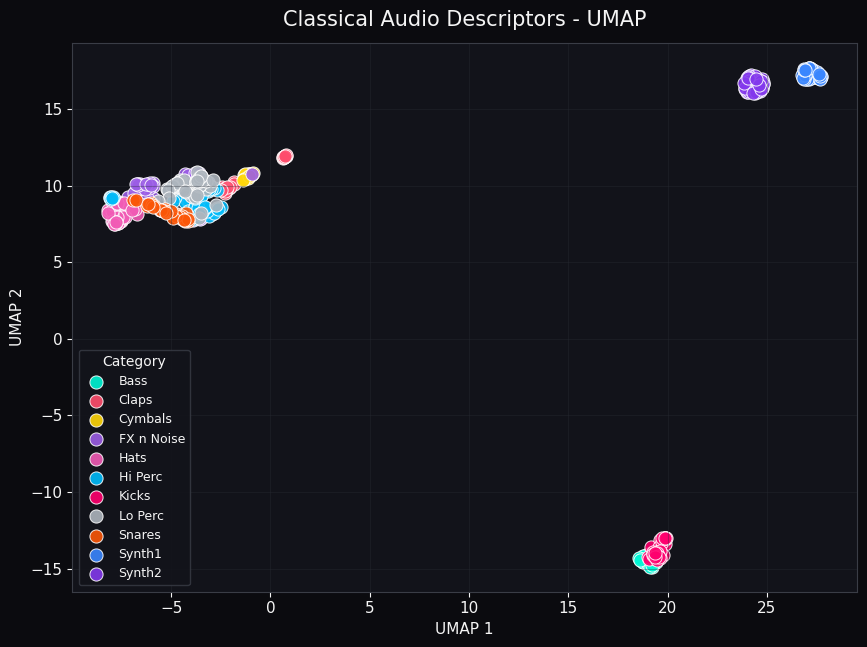

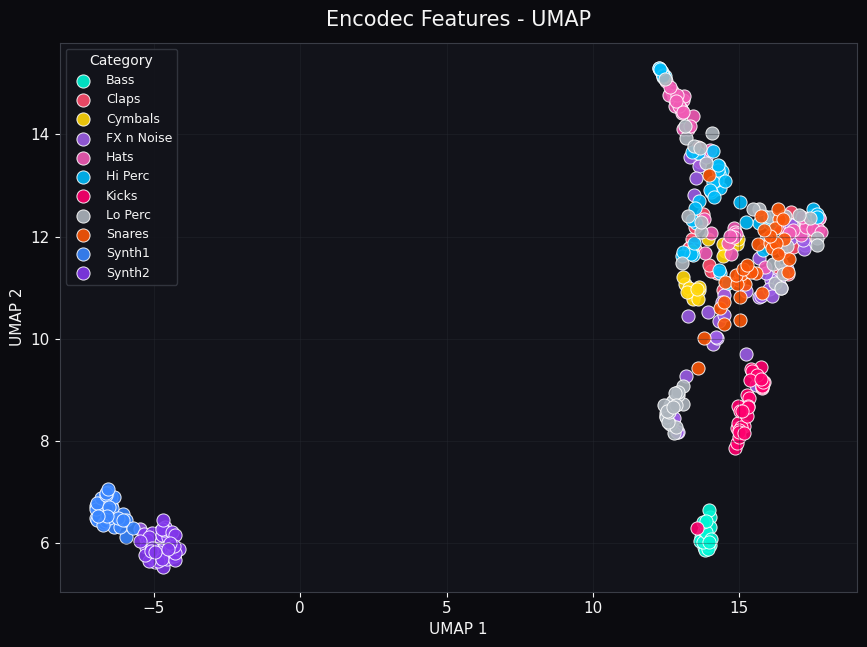

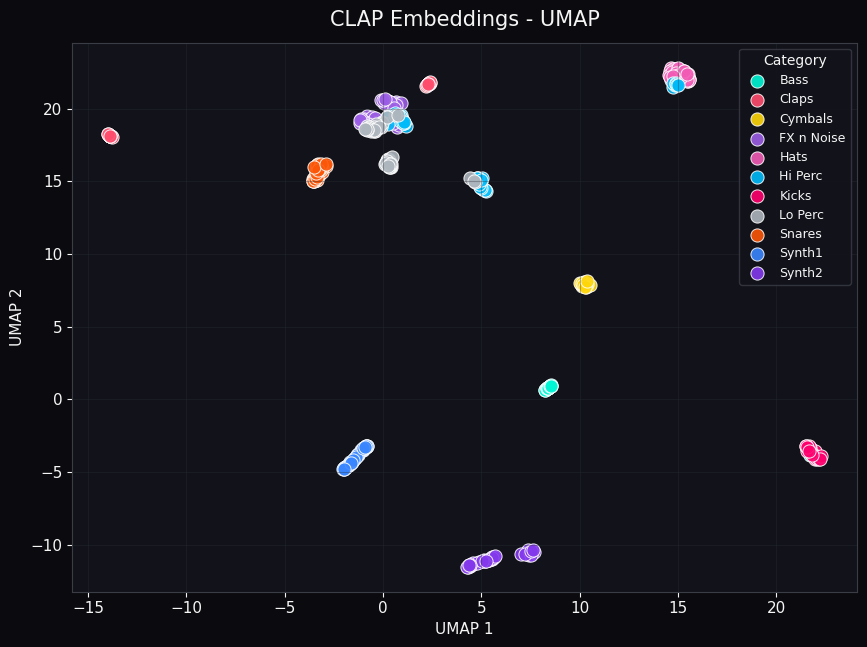

In [188]:
Path("figures_musicradar").mkdir(exist_ok=True)

save_dark_plot(plot_classical, "Classical Audio Descriptors - UMAP", "figures_musicradar/classical_umap_dark.png")
save_dark_plot(plot_encodec, "Encodec Features - UMAP", "figures_musicradar/encodec_umap_dark.png")
save_dark_plot(plot_clap, "CLAP Embeddings - UMAP", "figures_musicradar/clap_umap_dark.png")